In [22]:
import numpy as np
from layers import *
from transforms import RandomCrop, RandomRotate, RandomZoom, ToTensor, Compose
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from neural_networks import *
import torchvision.transforms as T
from collections import defaultdict
import random

np.random.seed(42)

# Task1


## 1.1 Linear

In [23]:
layer = Linear(3, 2)
x = np.array([[1, 2, 3]])

out = layer(x)
print("Выход:", out.round(3))

layer.backward(np.array([[1, -1]]))  # градиент сверху
print("Градиент по W:\n", layer.dW.round(3))
print("Градиент по b:", layer.db.round(3))

Выход: [[-1.519 -0.841]]
Градиент по W:
 [[ 1 -1]
 [ 2 -2]
 [ 3 -3]]
Градиент по b: [ 1 -1]


## 1.2 Batch norm

In [24]:
bn = BatchNorm(3)
bn.train()

x = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)

out = bn(x)
print("После BatchNorm:\n", out.round(3))

bn.backward(np.ones_like(out))
print("Градиенты по gamma:", bn.dgamma.round(3))
print("Градиенты по beta: ", bn.dbeta.round(3))

После BatchNorm:
 [[-1.225 -1.225 -1.225]
 [ 0.     0.     0.   ]
 [ 1.225  1.225  1.225]]
Градиенты по gamma: [0. 0. 0.]
Градиенты по beta:  [3. 3. 3.]


## 1.3 Dropout

In [25]:
drop = Dropout(p=0.5)
drop.train()  # важно!

x = np.ones((1, 6))
out = drop(x)
print("После Dropout:", out)
# → например [[0. 2. 0. 2. 2. 0.]]  (масштабировано ×2)

dx = drop.backward(np.ones_like(out))
print("Градиент:    ", dx)
# → тот же паттерн, но ×2

После Dropout: [[0. 2. 2. 2. 0. 2.]]
Градиент:     [[0. 2. 2. 2. 0. 2.]]


## 1.4 ReLU

In [26]:
relu = ReLU()
x = np.array([[-2, -1, 0, 1, 2]])

out = relu(x)
print("ReLU(x):     ", out)
# → [0. 0. 0. 1. 2.]

dx = relu.backward(np.ones_like(out))
print("Градиент:    ", dx)
# → [0. 0. 0. 1. 1.]

ReLU(x):      [[0 0 0 1 2]]
Градиент:     [[0 0 0 1 1]]


## 1.4.2 Sigmoid

In [27]:
sig = Sigmoid()
x = np.array([[-2, 0, 2]])

out = sig(x)
print("Sigmoid(x):  ", out.round(4))
# → [0.1192  0.5     0.8808]

dx = sig.backward(np.ones_like(out))
print("Градиент:    ", dx.round(4))
# → [0.10499  0.25    0.10499]

Sigmoid(x):   [[0.1192 0.5    0.8808]]
Градиент:     [[0.105 0.25  0.105]]


## 1.4.3 Softmax
рассматриваем softmax как отдельный слой (не рассматриваем как последний слой перед CE Loss)

In [28]:
sm = Softmax()
logits = np.array([[1, 2, 3]])  # один пример

probs = sm(logits)
print("Вероятности:", probs.round(4))
# → [[0.090  0.245  0.665]]

# имитируем правильный класс = 2
dout = probs.copy()
dout[0, 2] -= 1

dx = sm.backward(dout)
print("Градиент по логитам:", dx.round(4))
# → [[0.022, 0.097, –0.119]]

Вероятности: [[0.09   0.2447 0.6652]]
Градиент по логитам: [[ 0.022   0.0978 -0.1198]]


# Task 2

In [29]:
img_pil = Image.open("./data/image.jpg") 
img_np  = np.array(img_pil)                     # (H, W, 3)
img = torch.from_numpy(img_np).permute(2, 0, 1).float()   # (3, H, W)

In [30]:
torch.manual_seed(42)
noise_mask = torch.rand_like(img) < 0.25
salt_mask  = torch.rand_like(img) < 0.15

img_noisy = img.clone()
img_noisy[noise_mask] = 255.0
img_noisy[noise_mask & ~salt_mask] = 0.0

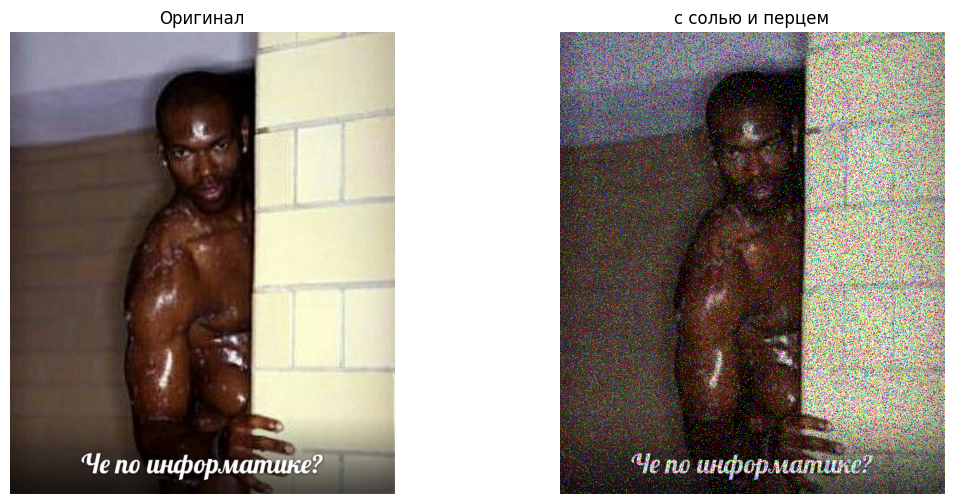

In [31]:
plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Оригинал")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_noisy.permute(1,2,0).to(torch.uint8))   
plt.title("с солью и перцем")
plt.axis('off')
plt.show()

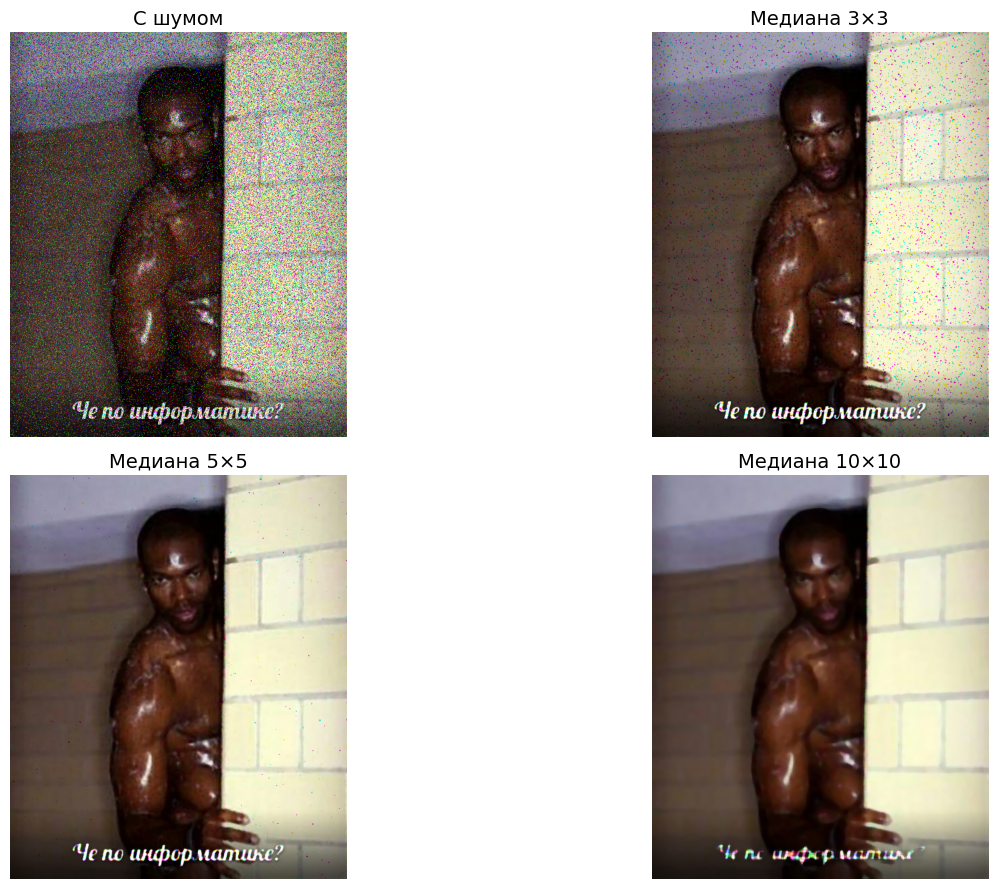

In [32]:
kernels = [3, 5, 10]     

results = [img_noisy]
titles  = ["С шумом"]

for k in kernels:
    out = median_filter(img_noisy, k)
    results.append(out.squeeze(0))
    titles.append(f"Медиана {k}×{k}")

plt.figure(figsize=(16, 9))
for i, (tensor, title) in enumerate(zip(results, titles), 1):
    plt.subplot(2, 2, i)
    plt.imshow(tensor.permute(1,2,0).to(torch.uint8))
    plt.title(title, fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Task 3

In [33]:
img = Image.open("data/image.jpg")
draw = ImageDraw.Draw(img)

crop = RandomCrop(1.0, (200, 200))  # p=1 чтобы всегда применялось
rotate = RandomRotate(1.0, 45)
zoom = RandomZoom(1.0, (0.05, 0.2))
to_tensor = ToTensor()
compose = Compose([crop, rotate, zoom])

In [34]:
img_crop = crop(img)
img_rotate = rotate(img)
img_zoom = zoom(img)
img_compose = compose(img)

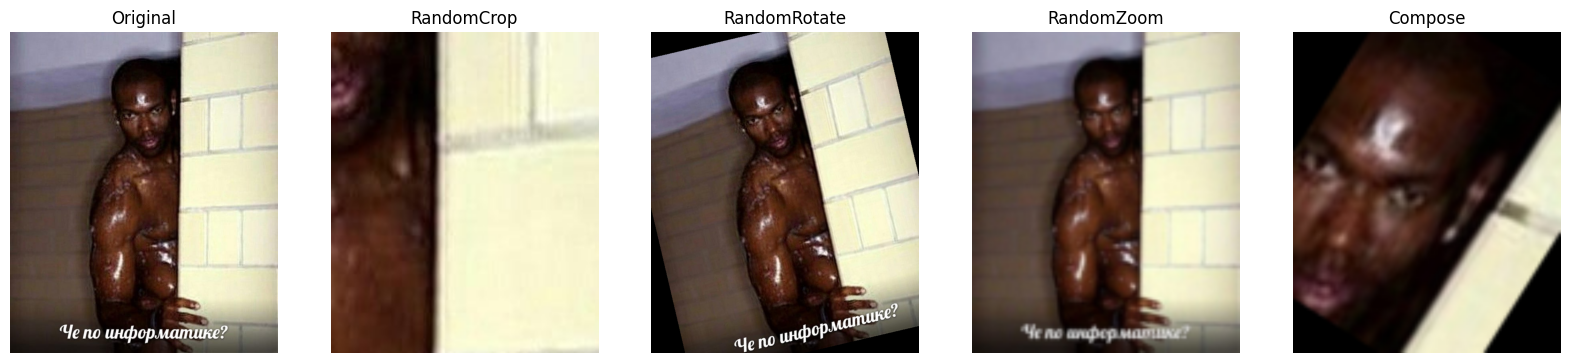

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(img);
axes[0].set_title("Original");
axes[0].axis('off')
axes[1].imshow(img_crop);
axes[1].set_title("RandomCrop");
axes[1].axis('off')
axes[2].imshow(img_rotate);
axes[2].set_title("RandomRotate");
axes[2].axis('off')
axes[3].imshow(img_zoom);
axes[3].set_title("RandomZoom");
axes[3].axis('off')
axes[4].imshow(img_compose);
axes[4].set_title("Compose");
axes[4].axis('off')
plt.show()

# Task 4

Использована модель с занятия, лежит в `./neural_networks/cnn.py`

In [36]:
train_raw = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

# Эксперименты
experiments = [
    {"name": "Rotate + Crop + Zoom p=0.7", "transform": Compose([RandomRotate(p=0.7, degrees=25, mode = "L"),
                                                                 RandomCrop(p=0.7, crop_size=(20, 20), mode = "L"),
                                                                 RandomZoom(p=0.7, zoom_range=(0.8, 1.2), mode = "L"),
                                                                 to_tensor])},
    {"name": "Без аугментаций", "transform": Compose([to_tensor])},
    {"name": "Rotate p=0.5", "transform": Compose([RandomRotate(p=0.5, degrees=180, mode = "L"), to_tensor])},
    {"name": "Rotate + Crop p=0.5", "transform": Compose([RandomRotate(p=0.5, degrees=180, mode = "L"),
                                                          RandomCrop(p=0.5, crop_size=(20, 20), mode = "L"), to_tensor])},
    
]

Устройство: cuda


In [40]:
results = {}
for exp in experiments:
    print(f"\n{'=' * 70}")
    print(f"ЭКСПЕРИМЕНТ: {exp['name']}")
    print('=' * 70)
    set_seed(42)

    train_dataset = MyDataset(train_raw, exp["transform"])
    test_dataset = MyDataset(test_raw, to_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    model = NeuralNetwork(device).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

    val_accs = []
    best_acc = 0

    for epoch in range(10):
        print(f"Эпоха {epoch + 1}/10")
        model.train_epoch(train_loader, loss_fn, optimizer)
        acc = model.test_epoch(test_loader, loss_fn)
        val_accs.append(acc)
        best_acc = max(best_acc, acc)

    results[exp["name"]] = val_accs
    print(f"→ Лучшая точность: {best_acc:.4f}")


ЭКСПЕРИМЕНТ: Rotate + Crop + Zoom p=0.7
Эпоха 1/10
  loss: 2.417873  [   64/60000]
  loss: 1.300838  [ 6464/60000]
  loss: 1.051549  [12864/60000]
  loss: 0.839703  [19264/60000]
  loss: 0.893043  [25664/60000]
  loss: 1.090075  [32064/60000]
  loss: 0.764866  [38464/60000]
  loss: 0.947954  [44864/60000]
  loss: 0.904306  [51264/60000]
  loss: 0.914004  [57664/60000]
  test accuracy: 80.83%, Avg loss: 0.549038
Эпоха 2/10
  loss: 0.817369  [   64/60000]
  loss: 0.913533  [ 6464/60000]
  loss: 0.943019  [12864/60000]
  loss: 0.755486  [19264/60000]
  loss: 0.675029  [25664/60000]
  loss: 0.540150  [32064/60000]
  loss: 0.826936  [38464/60000]
  loss: 0.721186  [44864/60000]
  loss: 0.690891  [51264/60000]
  loss: 1.026796  [57664/60000]
  test accuracy: 78.28%, Avg loss: 0.611139
Эпоха 3/10
  loss: 0.722106  [   64/60000]
  loss: 0.678347  [ 6464/60000]
  loss: 0.712697  [12864/60000]
  loss: 0.649524  [19264/60000]
  loss: 0.870187  [25664/60000]
  loss: 0.666736  [32064/60000]
  loss

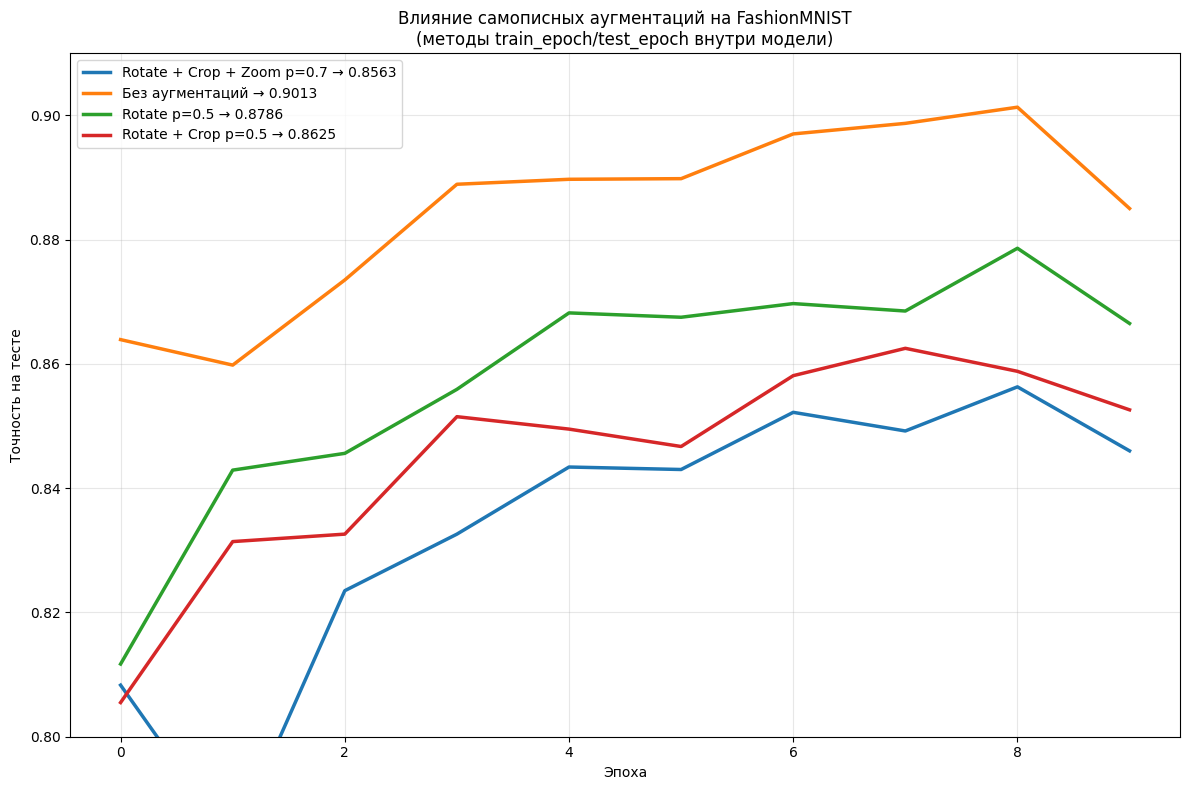

In [41]:
plt.figure(figsize=(12, 8))
for name, accs in results.items():
    plt.plot(accs, label=f"{name} → {max(accs):.4f}", linewidth=2.5)

plt.title("Влияние самописных аугментаций на FashionMNIST\n(методы train_epoch/test_epoch внутри модели)")
plt.xlabel("Эпоха")
plt.ylabel("Точность на тесте")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.80, 0.91)
plt.tight_layout()
plt.show()